# How big does a battery have to be to cover redispatch?

Sizing view over the **entire** ÜNB redispatch dataset (2013–2025, no plant-match
required). Each redispatch event has three numbers we care about:

- **power** it demanded (`MAXIMALE_LEISTUNG_MW` — the peak the grid needed),
- **energy** it moved (`GESAMTE_ARBEIT_MWH`),
- **duration** it ran (`ENDE − BEGINN`).

A battery of *power* `P` (MW) and *duration* `D` (h) has usable energy `E = P·D` (MWh).
We say it **fully covers** an event when it can meet both limits:

$$P_\text{batt} \ge P_\text{event} \quad\text{and}\quad P_\text{batt}\cdot D_\text{batt} \ge E_\text{event}.$$

The notebook produces, in order:

1. **Event landscape** — how long events run and how much energy they need (marginals + joint density).
2. **Coverage heatmaps** — prettier remakes of the size grid, by *event count* and by *energy*.
3. **Sizing curves** — the same information as smooth "how big for X %" frontiers.

Inputs: `2025-09-17 Redispatch Export 2013-2020.csv`, `Redispatch_Daten(3).csv`.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ---- house style: clean, seminar-ready ----------------------------------
sns.set_theme(style="white", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#444",
    "axes.linewidth": 0.8,
    "figure.facecolor": "white",
})
ACCENT   = "#2b6f8c"   # teal
ACCENT2  = "#d1793b"   # warm orange
INK      = "#22333b"

DATA_DIR = Path(".").resolve()
FILES = [DATA_DIR / "2025-09-17 Redispatch Export 2013-2020.csv",
         DATA_DIR / "Redispatch_Daten(3).csv"]
for p in FILES:
    assert p.exists(), p

# Where figures get written for the paper
FIGDIR = DATA_DIR / "figures_sizing"
FIGDIR.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight", facecolor="white")
    fig.savefig(FIGDIR / f"{name}.pdf", bbox_inches="tight", facecolor="white")


## Load + clean

Same conventions as the other notebooks: strip whitespace (kills the phantom
trailing-space duplicate in `RICHTUNG`), German `%d.%m.%Y` dates, comma→dot decimals,
coerce stray text to `NaN`.

In [2]:
def load_redispatch(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";", encoding="utf-8", on_bad_lines="skip", low_memory=False)
    for c in df.select_dtypes(include="object").columns:
        df[c] = df[c].astype(str).str.strip().replace({"nan": np.nan})
    df["ts_start"] = pd.to_datetime(df["BEGINN_DATUM"] + " " + df["BEGINN_UHRZEIT"].fillna("00:00"),
                                    format="%d.%m.%Y %H:%M", errors="coerce")
    df["ts_end"]   = pd.to_datetime(df["ENDE_DATUM"] + " " + df["ENDE_UHRZEIT"].fillna("00:00"),
                                    format="%d.%m.%Y %H:%M", errors="coerce")
    df["duration_h"] = (df["ts_end"] - df["ts_start"]).dt.total_seconds() / 3600
    for c in ["MITTLERE_LEISTUNG_MW", "MAXIMALE_LEISTUNG_MW", "GESAMTE_ARBEIT_MWH"]:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace(",", ".", regex=False), errors="coerce")
    df["year"] = df["ts_start"].dt.year
    return df

rd = pd.concat([load_redispatch(p) for p in FILES], ignore_index=True)
print(f"raw rows: {len(rd):,}  |  span {rd.ts_start.min().date()} -> {rd.ts_start.max().date()}")
print(f"total redispatched energy: {rd['GESAMTE_ARBEIT_MWH'].sum()/1e6:.1f} TWh")


raw rows: 123,362  |  span 2013-04-02 -> 2026-06-22
total redispatched energy: 182.0 TWh


### Event frame + coverage config

One knob decides the whole analysis: which power column defines "the power an event
demanded". `MAXIMALE_LEISTUNG_MW` is the honest choice for *full* coverage — the battery
has to meet the **peak**, not the average. Switch `POWER_COL` to `MITTLERE_LEISTUNG_MW`
for an average-power ("energy-shifting") reading.

We drop rows with missing power/energy/duration and trim durations to `(0, 48] h`
(a handful of legacy multi-day reserve rows otherwise skew everything).

In [3]:
POWER_COL = "MAXIMALE_LEISTUNG_MW"   # <- try "MITTLERE_LEISTUNG_MW" for the average-power view

ev = rd.dropna(subset=[POWER_COL, "GESAMTE_ARBEIT_MWH", "duration_h"]).copy()
ev = ev[(ev["duration_h"] > 0) & (ev["duration_h"] <= 48)]
ev = ev[(ev[POWER_COL] > 0) & (ev["GESAMTE_ARBEIT_MWH"] > 0)]

ev["p_mw"]  = ev[POWER_COL]
ev["e_mwh"] = ev["GESAMTE_ARBEIT_MWH"]
ev["d_h"]   = ev["duration_h"]

print(f"events used: {len(ev):,}  ({len(ev)/len(rd):.1%} of raw)")
print(f"power column: {POWER_COL}")
q = ev[["p_mw", "e_mwh", "d_h"]].quantile([.5, .9, .99]).round(1)
q.index = ["median", "p90", "p99"]
print(q.to_string())


events used: 123,003  (99.7% of raw)
power column: MAXIMALE_LEISTUNG_MW
          p_mw    e_mwh   d_h
median   190.0    496.2   4.8
p90      520.0   3870.0  18.0
p99     1265.0  14084.8  24.0


---
## 1 · Event landscape — how long, how much energy?

Before sizing anything: what do redispatch events actually look like? Both duration and
energy are heavy-tailed — most events are small and short, a few are enormous. The plots
below use **ECDFs** (easy to read "% of events below X") and a **joint density** so you can
see the two together.

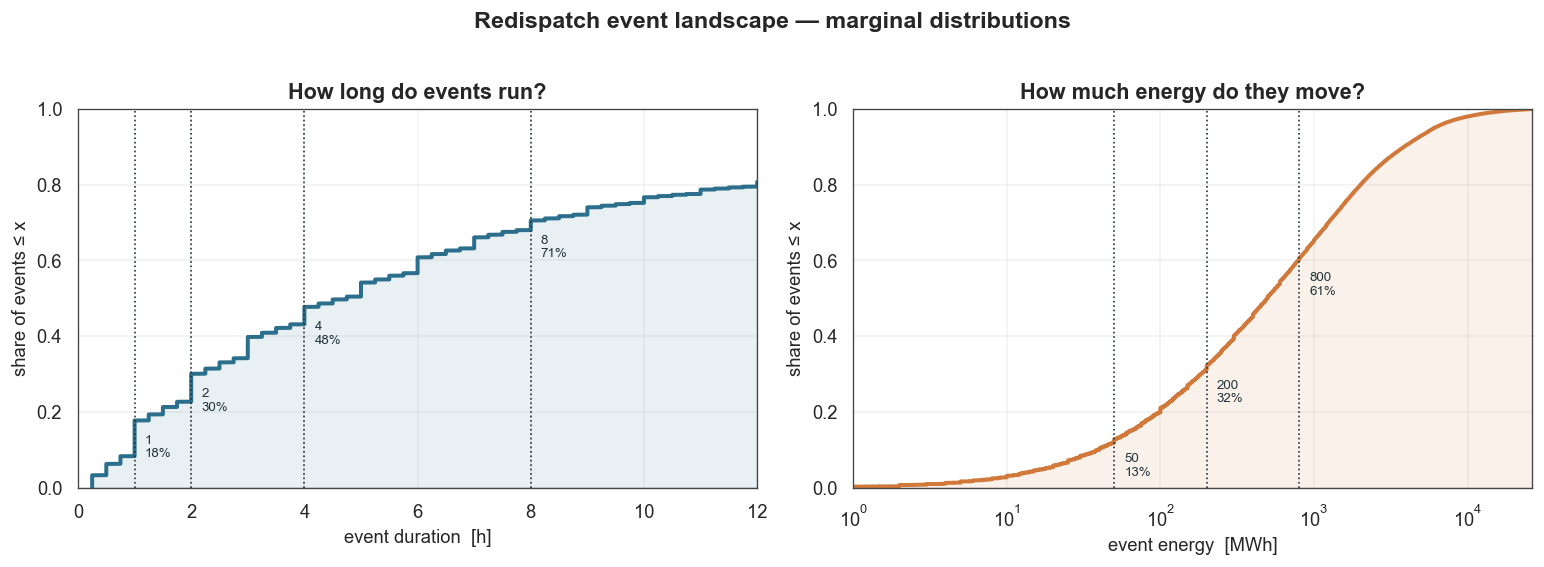

In [4]:
# --- 1a. Marginal ECDFs of duration and energy -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

def ecdf(ax, s, color, xlabel, logx=False, marks=()):
    s = np.sort(s.values)
    y = np.arange(1, len(s) + 1) / len(s)
    ax.plot(s, y, color=color, lw=2.4)
    ax.fill_between(s, y, color=color, alpha=0.10)
    if logx:
        ax.set_xscale("log")
    ax.set_ylim(0, 1); ax.set_ylabel("share of events ≤ x")
    ax.set_xlabel(xlabel)
    ax.grid(True, alpha=0.25)
    for mv in marks:
        share = (s <= mv).mean()
        ax.axvline(mv, color=INK, ls=":", lw=1)
        ax.annotate(f"{mv:g}\n{share:.0%}", (mv, share), textcoords="offset points",
                    xytext=(6, -22), fontsize=8, color=INK)

ecdf(axes[0], ev["d_h"], ACCENT, "event duration  [h]", marks=(1, 2, 4, 8))
axes[0].set_title("How long do events run?")
axes[0].set_xlim(0, 12)

ecdf(axes[1], ev["e_mwh"], ACCENT2, "event energy  [MWh]", logx=True, marks=(50, 200, 800))
axes[1].set_title("How much energy do they move?")
axes[1].set_xlim(1, ev["e_mwh"].quantile(0.999))

fig.suptitle("Redispatch event landscape — marginal distributions",
             y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout(); save(fig, "01_marginals_ecdf"); plt.show()


### 1b · Joint density with battery reference lines

Every event is a point in the **duration × power** plane; its **energy** is the area
`P·D`. The diagonal lines are **iso-energy contours** — a 4 h / 100 MW battery (400 MWh)
sits on the 400 MWh line and covers everything down-and-left of its power ceiling and
inside its energy contour. This one panel is the geometric heart of the sizing question.

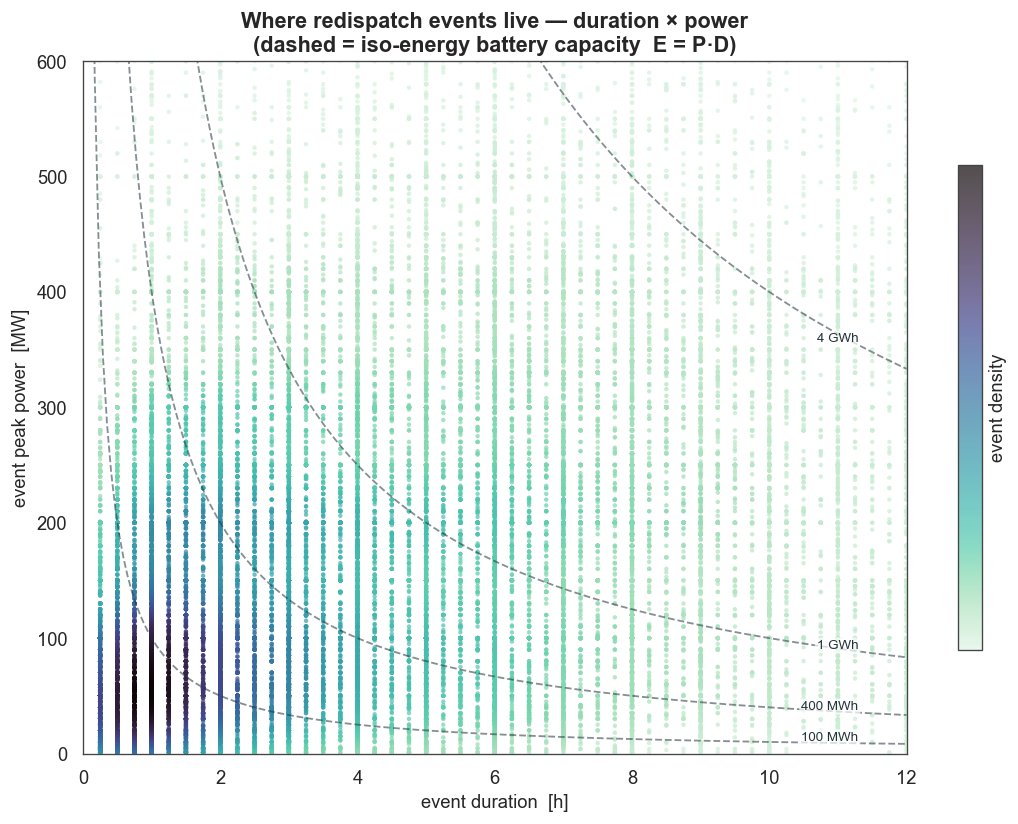

In [5]:
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(9.5, 7))

x = ev["d_h"].values
y = ev["p_mw"].values
m = (x <= 12) & (y <= 600)          # zoom to the bulk; tail handled by log elsewhere
xs, ys = x[m], y[m]

# density-coloured scatter (subsample for speed if huge)
if len(xs) > 40000:
    idx = np.random.default_rng(0).choice(len(xs), 40000, replace=False)
    xs_p, ys_p = xs[idx], ys[idx]
else:
    xs_p, ys_p = xs, ys
kde = gaussian_kde(np.vstack([xs_p, ys_p]))
dens = kde(np.vstack([xs_p, ys_p]))
order = dens.argsort()
sc = ax.scatter(xs_p[order], ys_p[order], c=dens[order], s=7, cmap="mako_r",
                alpha=0.7, linewidths=0)

# iso-energy (battery capacity) lines: E = P * D
dd = np.linspace(0.05, 12, 200)
for E, lab in [(100, "100 MWh"), (400, "400 MWh"), (1000, "1 GWh"), (4000, "4 GWh")]:
    ax.plot(dd, E / dd, color=INK, lw=1.1, ls="--", alpha=0.55)
    # anchor the label on the right edge (x≈11.3) where the four curves separate vertically
    xl = 11.3
    yl = E / xl
    if yl <= 580:
        ax.annotate(lab, (xl, yl), fontsize=8, color=INK, ha="right", va="bottom",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
    else:  # curve too steep to hit the right edge — label near the top instead
        ax.annotate(lab, (E / 560, 560), fontsize=8, color=INK, ha="left", va="top",
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))

ax.set_xlim(0, 12); ax.set_ylim(0, 600)
ax.set_xlabel("event duration  [h]"); ax.set_ylabel("event peak power  [MW]")
ax.set_title("Where redispatch events live — duration × power\n"
             "(dashed = iso-energy battery capacity  E = P·D)")
cb = plt.colorbar(sc, ax=ax, shrink=0.7); cb.set_label("event density"); cb.set_ticks([])
plt.tight_layout(); save(fig, "02_joint_duration_power"); plt.show()


---
## 2 · Coverage heatmaps

The size grid, remade. For each battery `(power P, duration D)` we compute the share of
events it fully covers. **Two weightings**, because they answer different questions:

- **by event count** — "what fraction of *interventions* could this battery have handled?"
- **by energy** — "what fraction of the *redispatched megawatt-hours* could it have absorbed?"

The energy-weighted view is the one that matters for grid impact: a battery that covers
90 % of events but misses the few giant ones absorbs far less than 90 % of the volume.

In [6]:
POWERS    = [10, 25, 50, 100, 200, 500]        # MW
DURATIONS = [1, 2, 4, 6, 8]                     # h

def coverage_grid(events, weight=None):
    p = events["p_mw"].values
    e = events["e_mwh"].values
    w = np.ones(len(events)) if weight is None else events[weight].values
    W = w.sum()
    G = np.zeros((len(POWERS), len(DURATIONS)))
    for i, P in enumerate(POWERS):
        for j, D in enumerate(DURATIONS):
            covered = (p <= P) & (e <= P * D)
            G[i, j] = w[covered].sum() / W * 100
    return pd.DataFrame(G, index=POWERS, columns=DURATIONS)

grid_count  = coverage_grid(ev)                       # % of events
grid_energy = coverage_grid(ev, weight="e_mwh")       # % of MWh
grid_count.round(1)


,1,2,4,6,8
10,2.1,2.5,2.9,3.0,3.0
25,4.4,5.4,6.1,6.3,6.4
50,9.1,11.6,13.7,14.5,14.9
100,18.0,23.9,28.6,30.6,31.4
200,30.5,40.4,48.7,52.3,53.9
500,50.4,64.7,77.8,83.2,85.7


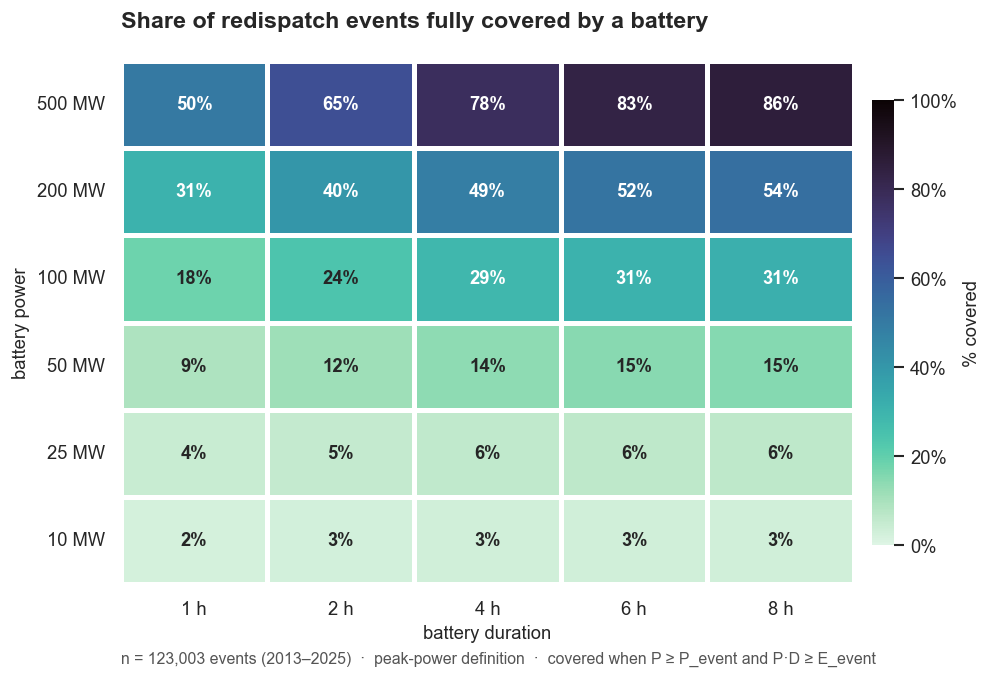

In [7]:
# Shared prettifier for the two heatmaps.
def pretty_heatmap(grid, title, subtitle, cmap, fname):
    fig, ax = plt.subplots(figsize=(8.6, 5.8))
    hm = sns.heatmap(
        grid, ax=ax, cmap=cmap, vmin=0, vmax=100,
        annot=True, fmt=".0f", annot_kws={"fontsize": 11, "fontweight": "bold"},
        linewidths=2, linecolor="white", square=False,
        cbar_kws={"label": "% covered", "shrink": 0.85, "pad": 0.02},
    )
    # append a % to each cell label
    for t in ax.texts:
        t.set_text(t.get_text() + "%")
    ax.set_xticklabels([f"{d} h" for d in grid.columns], rotation=0)
    ax.set_yticklabels([f"{p} MW" for p in grid.index], rotation=0)
    ax.set_xlabel("battery duration"); ax.set_ylabel("battery power")
    ax.invert_yaxis()   # small batteries at the bottom, like the original
    ax.set_title(f"{title}\n", loc="left", fontsize=14)
    ax.text(0, -0.15, subtitle, transform=ax.transAxes, fontsize=9.5, color="#555")
    hm.collections[0].colorbar.ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
    plt.tight_layout(); save(fig, fname); plt.show()

pretty_heatmap(
    grid_count,
    "Share of redispatch events fully covered by a battery",
    f"n = {len(ev):,} events (2013–2025)  ·  peak-power definition  ·  covered when P ≥ P_event and P·D ≥ E_event",
    "mako_r", "03_heatmap_count")


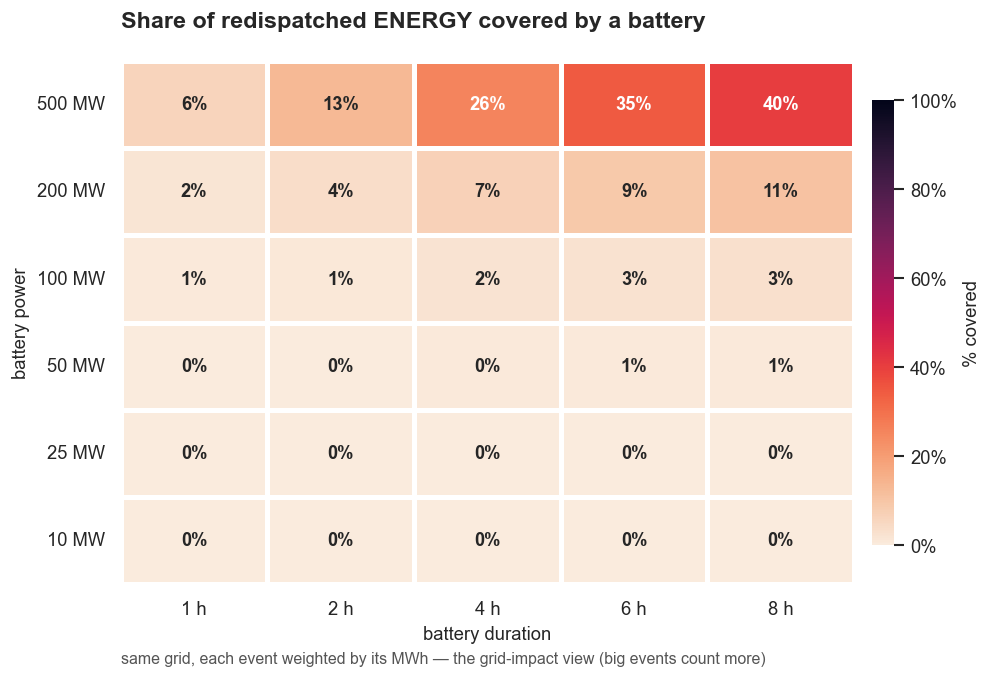

count − energy coverage gap (percentage points):


,1,2,4,6,8
10,2,3,3,3,3
25,4,5,6,6,6
50,9,11,13,14,14
100,18,23,27,28,28
200,29,37,42,43,43
500,44,52,52,49,45


In [8]:
pretty_heatmap(
    grid_energy,
    "Share of redispatched ENERGY covered by a battery",
    "same grid, each event weighted by its MWh — the grid-impact view (big events count more)",
    "rocket_r", "04_heatmap_energy")

# side-by-side gap: energy coverage always lags count coverage
print("count − energy coverage gap (percentage points):")
(grid_count - grid_energy).round(0).astype(int)


---
## 3 · Sizing curves — "how big for X %?"

The heatmap as smooth frontiers. Read it the other way: pick a coverage target on the
y-axis, drop to the curve for your duration, read the required power on the x-axis.
Continuous power sweep, one line per duration.

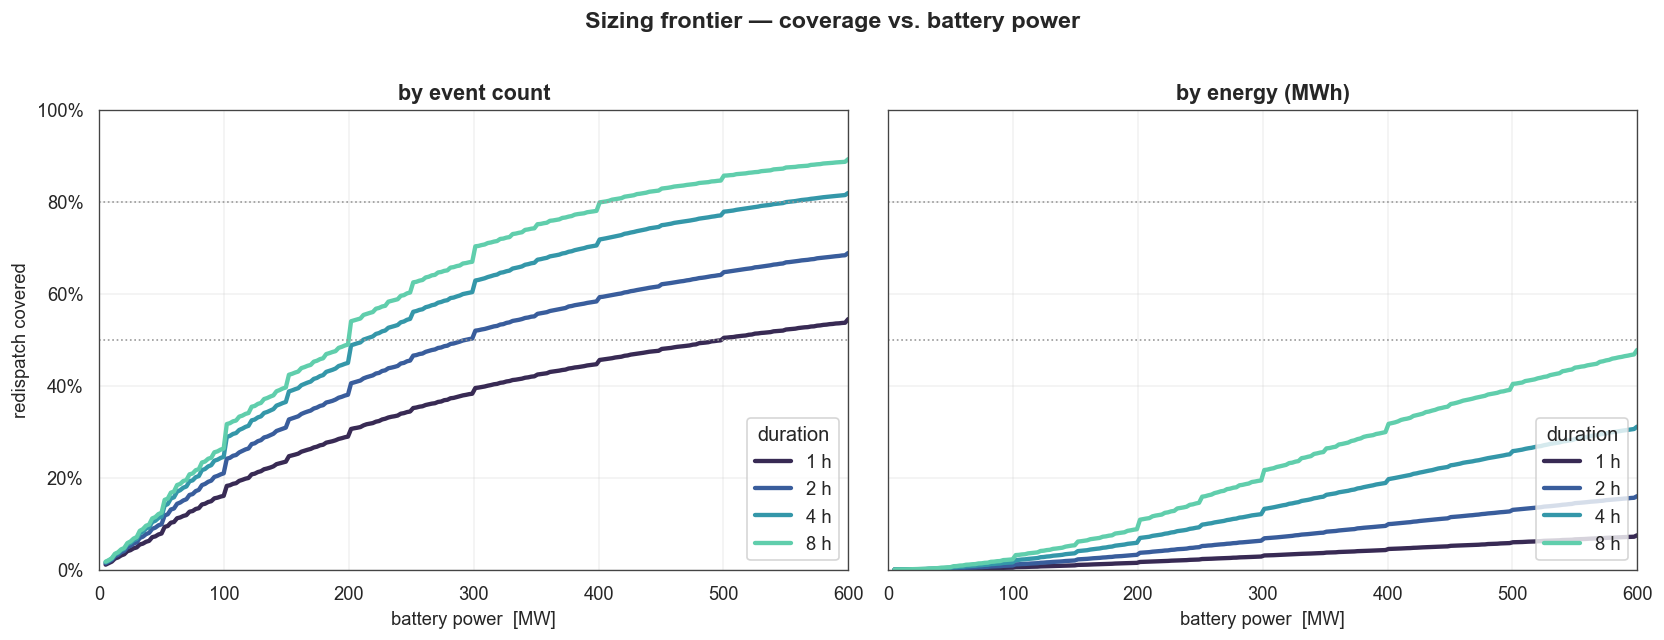

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
power_sweep = np.linspace(5, 600, 240)
dur_lines   = [1, 2, 4, 8]
palette     = sns.color_palette("mako", n_colors=len(dur_lines))

p_arr, e_arr = ev["p_mw"].values, ev["e_mwh"].values
w_e = e_arr / e_arr.sum()

def cov_curve(P, D, weighted):
    covered = (p_arr <= P) & (e_arr <= P * D)
    return (w_e[covered].sum() if weighted else covered.mean()) * 100

for ax, weighted, ttl in [(axes[0], False, "by event count"),
                          (axes[1], True,  "by energy (MWh)")]:
    for D, col in zip(dur_lines, palette):
        ys = [cov_curve(P, D, weighted) for P in power_sweep]
        ax.plot(power_sweep, ys, color=col, lw=2.6, label=f"{D} h")
    ax.axhline(50, color="#999", ls=":", lw=1); ax.axhline(80, color="#999", ls=":", lw=1)
    ax.set_xlabel("battery power  [MW]")
    ax.set_title(ttl)
    ax.set_xlim(0, 600); ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.25)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
    ax.legend(title="duration", loc="lower right", frameon=True)
axes[0].set_ylabel("redispatch covered")
fig.suptitle("Sizing frontier — coverage vs. battery power",
             y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout(); save(fig, "05_sizing_curves"); plt.show()


### 3b · The trade-off in one line

If you only keep one figure: coverage against **installed energy capacity** `E = P·D`,
for both weightings. It collapses the whole grid onto the single quantity that costs
money — MWh of battery — and shows the sharp diminishing returns past a few hundred MWh.

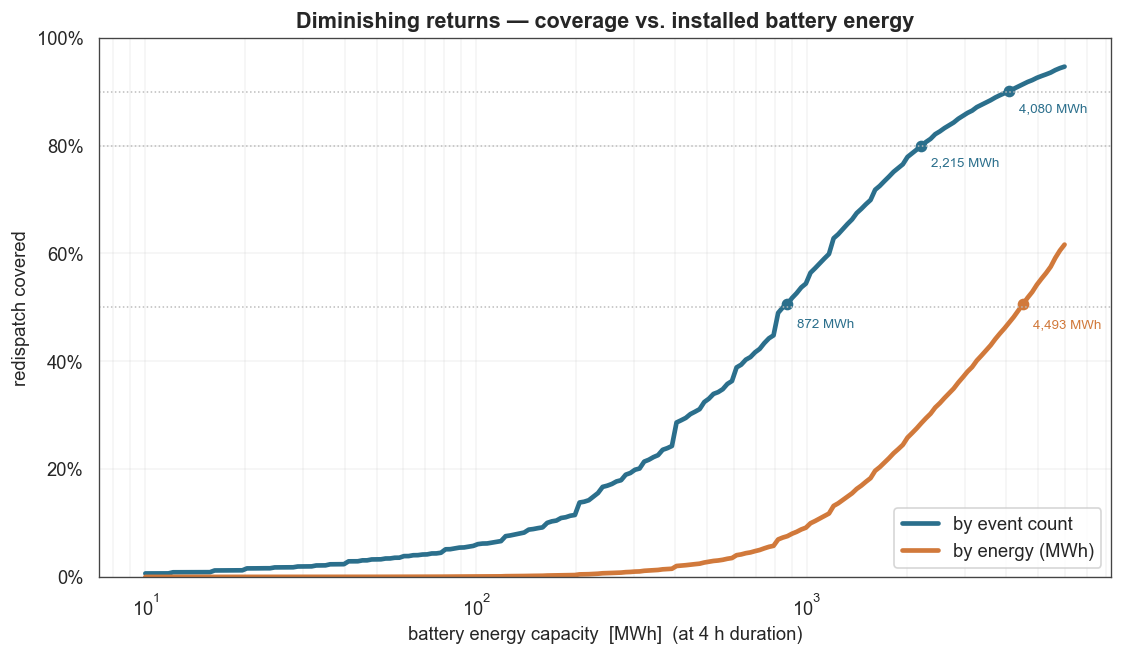

In [10]:
fig, ax = plt.subplots(figsize=(9.5, 5.6))
cap_sweep = np.logspace(np.log10(10), np.log10(6000), 200)   # MWh
# hold a 4 h C-rate: P = E / 4  (typical utility spec)
for weighted, col, lab in [(False, ACCENT, "by event count"),
                           (True,  ACCENT2, "by energy (MWh)")]:
    ys = []
    for E in cap_sweep:
        P = E / 4.0
        covered = (p_arr <= P) & (e_arr <= E)
        ys.append((w_e[covered].sum() if weighted else covered.mean()) * 100)
    ax.plot(cap_sweep, ys, color=col, lw=2.8, label=lab)
    # mark 50/80/90 %
    for tgt in (50, 80, 90):
        k = np.argmax(np.array(ys) >= tgt)
        if ys[k] >= tgt:
            ax.plot(cap_sweep[k], ys[k], "o", color=col, ms=6)
            ax.annotate(f"{cap_sweep[k]:,.0f} MWh", (cap_sweep[k], tgt),
                        textcoords="offset points", xytext=(6, -12), fontsize=8, color=col)

ax.set_xscale("log")
ax.set_xlabel("battery energy capacity  [MWh]  (at 4 h duration)")
ax.set_ylabel("redispatch covered")
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(decimals=0))
for tgt in (50, 80, 90):
    ax.axhline(tgt, color="#bbb", ls=":", lw=0.9)
ax.set_ylim(0, 100); ax.grid(True, alpha=0.2, which="both")
ax.legend(loc="lower right", frameon=True)
ax.set_title("Diminishing returns — coverage vs. installed battery energy")
plt.tight_layout(); save(fig, "06_capacity_tradeoff"); plt.show()


---
### Notes for the paper

- **Definition is descriptive, not operational.** "Fully covers" tests only whether one
  battery's nameplate power/energy *envelopes* one event. It is **not** a dispatch model:
  it ignores state-of-charge, back-to-back events, simultaneity across the grid, and
  round-trip losses. Read it as an upper bound on what a single asset of that size could
  in principle absorb.
- **Peak vs. average power.** Default uses `MAXIMALE_LEISTUNG_MW` (peak). Flip `POWER_COL`
  to `MITTLERE_LEISTUNG_MW` to size against average power — coverage rises, since events
  rarely sit at their peak the whole time.
- **Count vs. energy weighting is the key contrast.** The energy-weighted heatmap/curves
  sit well below the count-weighted ones: covering most *events* still leaves most
  *megawatt-hours* uncovered, because a few very large events dominate the volume. Good
  hook for the discussion on what colocated batteries can realistically offset.
- All figures are written to `figures_sizing/` as PNG + PDF.

---
## Appendix — MaStR buildout timeline: installed vs. planned battery capacity (2018–2030)

Quick sizing context for the analysis above: how much battery power capacity already
exists in Germany, and how much is registered as planned. Source: MaStR
(`bnetza_mastr_storage_raw.csv`), filtered to `Technologie == "Batterie"` (excludes
pumped hydro, hydrogen, flywheel, compressed air). Power capacity is
`Nettonennleistung` (falls back to `Bruttoleistung`) in kW → GW; MaStR does not report
energy capacity (MWh) for most units, so this is power, not energy.

- **Installed** = status `In Betrieb`, plotted by `Inbetriebnahmedatum`.
- **Planned** = status `In Planung`, plotted by `GeplantesInbetriebnahmedatum`.
- The last 1–2 years of both series are under-reported (registration lag) — read the
  tail as a floor, not a ceiling. A handful of far-future placeholder planned dates
  (out to 2054) are silently dropped by clipping to the 2018–2030 window.

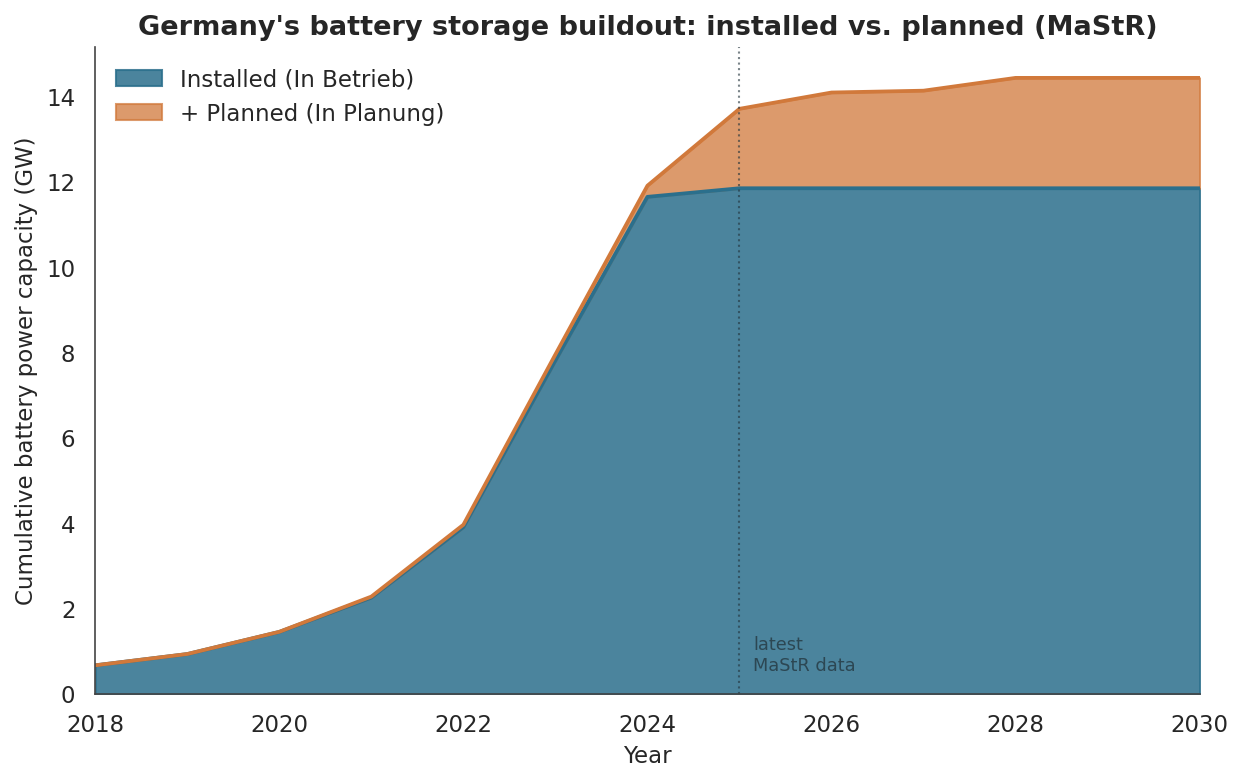

Installed by 2025: 11.85 GW
Installed + planned registered through 2030: 14.44 GW


In [ ]:
MASTR_PATH = DATA_DIR.parent / "bnetza_mastr_storage_raw.csv"
assert MASTR_PATH.exists(), MASTR_PATH

USECOLS = ["EinheitBetriebsstatus", "Bruttoleistung", "Nettonennleistung",
           "Inbetriebnahmedatum", "GeplantesInbetriebnahmedatum", "Technologie"]
mastr = pd.read_csv(MASTR_PATH, usecols=USECOLS, low_memory=False)

# batteries only (drops Pumpspeicher / Wasserstoffspeicher / Schwungrad / Druckluft)
bat = mastr[mastr["Technologie"] == "Batterie"].copy()
bat["power_gw"] = bat["Nettonennleistung"].fillna(bat["Bruttoleistung"]) / 1e6   # kW -> GW

bat["inb_year"]  = pd.to_datetime(bat["Inbetriebnahmedatum"], errors="coerce").dt.year
bat["plan_year"] = pd.to_datetime(bat["GeplantesInbetriebnahmedatum"], errors="coerce").dt.year

YEARS = list(range(2018, 2031))

installed = bat[bat["EinheitBetriebsstatus"] == "In Betrieb"].dropna(subset=["inb_year"]).copy()
planned   = bat[bat["EinheitBetriebsstatus"] == "In Planung"].dropna(subset=["plan_year"]).copy()
installed["inb_year"] = installed["inb_year"].astype(int)
planned["plan_year"]  = planned["plan_year"].astype(int)

# capacity already installed before 2018 (a handful of early pilot projects)
baseline_installed = installed.loc[installed["inb_year"] < 2018, "power_gw"].sum()

inst_by_year = (installed[installed["inb_year"] >= 2018]
                .groupby("inb_year")["power_gw"].sum().reindex(YEARS, fill_value=0))
plan_by_year = planned.groupby("plan_year")["power_gw"].sum().reindex(YEARS, fill_value=0)
# reindexing to YEARS also clips the long tail of far-future placeholder planned dates

cum_installed = inst_by_year.cumsum() + baseline_installed
cum_total     = cum_installed + plan_by_year.cumsum()

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.fill_between(YEARS, 0, cum_installed, color=ACCENT, alpha=0.85, label="Installed (In Betrieb)")
ax.fill_between(YEARS, cum_installed, cum_total, color=ACCENT2, alpha=0.75, label="+ Planned (In Planung)")
ax.plot(YEARS, cum_installed, color=ACCENT, lw=1.8)
ax.plot(YEARS, cum_total, color=ACCENT2, lw=1.8)

last_data_year = int(installed["inb_year"].max())
ax.axvline(last_data_year, color=INK, lw=1, ls=":", alpha=0.6)
ax.text(last_data_year + 0.15, ax.get_ylim()[1] * 0.03, "latest\nMaStR data",
        fontsize=8.5, color=INK, alpha=0.75, va="bottom")

ax.set_xlim(2018, 2030)
ax.set_ylim(bottom=0)
ax.set_xlabel("Year")
ax.set_ylabel("Cumulative battery power capacity (GW)")
ax.set_title("Germany's battery storage buildout: installed vs. planned (MaStR)")
ax.legend(loc="upper left", frameon=False)
sns.despine(ax=ax)

save(fig, "05_mastr_installed_vs_planned_capacity")
plt.show()

print(f"Installed by {last_data_year}: {cum_installed.loc[last_data_year]:.2f} GW")
print(f"Installed + planned registered through 2030: {cum_total.iloc[-1]:.2f} GW")